# CKD Screening Paper — Research-Grade MLWA Experimental Pipeline (v2)

This notebook replaces the earlier experiment design with a more defensible
development/evaluation workflow for a **Machine Learning with Applications**
submission.

## Major methodological changes

1. **2017–2018 is the development cohort; 2021–2023 is the untouched temporal
   transport-validation cohort.** We do not repeatedly tune against 2021–2023.
2. **Nested cross-validation** replaces a single train/validation/test split for
   internal model comparison.
3. **No synthetic oversampling in the primary analysis.** SMOTE/SMOTEENN are
   retained only as sensitivity analyses because they can distort probability
   calibration.
4. **Calibration is a core endpoint**, not an afterthought.
5. **Threshold-independent metrics are primary.** A single F1-maximizing cutoff
   is no longer used as the central clinical claim.
6. A screening operating point is chosen **only from development out-of-fold
   predictions**, targeting 80% sensitivity, and then frozen before temporal
   validation.
7. **Race/ethnicity is not used as a primary predictor.** It is retained for
   subgroup performance analysis.
8. The physical-activity variable is excluded from the primary model because the
   questionnaire is not harmonized across the two cycles.
9. Arbitrary/redundant engineered features such as BMI category, age×BMI and
   measured-hypertension flags are excluded from the primary predictor set.
10. **NHANES MEC survey weights** are added for population-weighted sensitivity
    analyses.
11. Subgroup results include uncertainty and are described as **performance
    heterogeneity**, not proof of fairness.
12. 2021–2023 is called **temporal validation / transport evaluation**, not a
    wholly independent external dataset.
13. The outcome is best described in the manuscript as a **single-visit CKD
    screening phenotype / CKD markers**, because NHANES cannot establish
    persistence for ≥3 months.

## Primary predictor set

- age
- sex
- education
- income-to-poverty ratio
- prior hypertension diagnosis
- prior diabetes diagnosis
- BMI
- waist circumference
- smoking history
- alcohol intake
- mean systolic blood pressure
- mean diastolic blood pressure

Race/ethnicity and physical activity are evaluated separately rather than built
into the primary deployed model.

In [1]:
# =========================================================
# 0. Google Colab + package setup
# =========================================================
from google.colab import drive
drive.mount("/content/drive")

!pip -q install -U lightgbm xgboost imbalanced-learn statsmodels requests

from pathlib import Path

ROOT = Path("/content/drive/MyDrive/Shuvo-Paper")
DATA_PATH = ROOT / "nhanes_ckd_risk_clean.csv"
RESULTS_DIR = ROOT / "mlwa_research_grade_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset:", DATA_PATH)
print("Exists:", DATA_PATH.exists())
print("Results:", RESULTS_DIR)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 3.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
Dataset: /content/drive/MyDrive/Shuvo-Paper/nhanes_ckd_risk_clean.csv
Exists: True
Results: /content/drive/MyDrive/Shuvo-Paper/mlwa_research_grade_results


In [2]:
# =========================================================
# 1. Imports and reproducibility
# =========================================================
import io
import json
import math
import warnings
import platform
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from scipy.stats import randint, uniform, loguniform

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV,
    cross_val_predict
)
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

RANDOM_STATE = 42
OUTER_FOLDS = 5
INNER_FOLDS = 5
N_ITER = 20
N_BOOT = 2000

np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")

print("Python:", platform.python_version())

Python: 3.13.15


## 2. Load the cleaned 2017–2018 development cohort

The current cleaned file is retained so that the revised analysis stays directly
connected to the manuscript dataset. The analysis features are redefined rather
than inheriting the earlier engineered feature set.

In [3]:
df_raw = pd.read_csv(DATA_PATH)

required = [
    "SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH1", "DMDEDUC2", "INDFMPIR",
    "has_htn_dx", "has_diabetes_dx", "BMXBMI", "BMXWAIST",
    "smoked_100_cigs", "ALQ130",
    "BPXSY1", "BPXSY2", "BPXSY3",
    "BPXDI1", "BPXDI2", "BPXDI3", "ckd"
]
missing = [c for c in required if c not in df_raw.columns]
if missing:
    raise ValueError(f"Required columns missing from cleaned file: {missing}")

df = df_raw.copy()
df["mean_sbp"] = df[["BPXSY1", "BPXSY2", "BPXSY3"]].mean(axis=1)
df["mean_dbp"] = df[["BPXDI1", "BPXDI2", "BPXDI3"]].mean(axis=1)

PRIMARY_FEATURES = [
    "RIDAGEYR",
    "RIAGENDR",
    "DMDEDUC2",
    "INDFMPIR",
    "has_htn_dx",
    "has_diabetes_dx",
    "BMXBMI",
    "BMXWAIST",
    "smoked_100_cigs",
    "ALQ130",
    "mean_sbp",
    "mean_dbp",
]

X_dev = df[PRIMARY_FEATURES].copy()
y_dev = df["ckd"].astype(int).copy()
seqn_dev = df["SEQN"].copy()

print("Development n:", len(df))
print("Unweighted CKD phenotype prevalence:", round(y_dev.mean(), 4))
print("Primary predictors:", PRIMARY_FEATURES)

Development n: 5533
Unweighted CKD phenotype prevalence: 0.1843
Primary predictors: ['RIDAGEYR', 'RIAGENDR', 'DMDEDUC2', 'INDFMPIR', 'has_htn_dx', 'has_diabetes_dx', 'BMXBMI', 'BMXWAIST', 'smoked_100_cigs', 'ALQ130', 'mean_sbp', 'mean_dbp']


## 3. Add NHANES survey weights and design variables

Because the study uses MEC examination/laboratory variables, `WTMEC2YR` is used
for population-weighted sensitivity analyses.

In [4]:
def read_xpt_url(url, timeout=120):
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    return pd.read_sas(io.BytesIO(r.content), format="xport")

DEMO_J_URL = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/DEMO_J.XPT"

demo_j = read_xpt_url(DEMO_J_URL)[
    ["SEQN", "WTMEC2YR", "SDMVPSU", "SDMVSTRA"]
].copy()

survey_dev = pd.DataFrame({"SEQN": seqn_dev}).merge(
    demo_j, on="SEQN", how="left", validate="one_to_one"
)

weighted_prev = np.average(
    y_dev,
    weights=survey_dev["WTMEC2YR"]
)

print("Survey-weighted CKD phenotype prevalence:", round(weighted_prev, 4))

Survey-weighted CKD phenotype prevalence: 0.1361


## 4. Leakage-safe preprocessing

In [5]:
def make_preprocessor(X):
    cat_cols = list(X.select_dtypes(exclude=np.number).columns)
    num_cols = list(X.select_dtypes(include=np.number).columns)

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ])

    return ColumnTransformer([
        ("cat", cat_pipe, cat_cols),
        ("num", num_pipe, num_cols)
    ])

def make_pipeline(model, X):
    return Pipeline([
        ("prep", make_preprocessor(X)),
        ("model", model)
    ])

## 5. Candidate models

A compact set of meaningfully different models is compared. Synthetic
oversampling is excluded from the primary experiment.

In [6]:
pos = int(y_dev.sum())
neg = int((1 - y_dev).sum())
imbalance_ratio = neg / pos

MODEL_SPECS = {
    "Logistic Regression": {
        "pipeline": make_pipeline(
            LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
            X_dev
        ),
        "params": {
            "model__C": loguniform(1e-3, 1e2),
            "model__class_weight": [None, "balanced"]
        }
    },

    "Random Forest": {
        "pipeline": make_pipeline(
            RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
            X_dev
        ),
        "params": {
            "model__n_estimators": randint(300, 900),
            "model__max_depth": [None, 4, 6, 8, 12],
            "model__min_samples_leaf": randint(1, 12),
            "model__max_features": ["sqrt", "log2", 0.5, 0.8],
            "model__class_weight": [None, "balanced", "balanced_subsample"]
        }
    },

    "HistGradientBoosting": {
        "pipeline": make_pipeline(
            HistGradientBoostingClassifier(random_state=RANDOM_STATE),
            X_dev
        ),
        "params": {
            "model__learning_rate": loguniform(0.01, 0.2),
            "model__max_iter": randint(100, 500),
            "model__max_leaf_nodes": randint(7, 40),
            "model__min_samples_leaf": randint(10, 60),
            "model__l2_regularization": loguniform(1e-4, 10)
        }
    },

    "XGBoost": {
        "pipeline": make_pipeline(
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                tree_method="hist"
            ),
            X_dev
        ),
        "params": {
            "model__n_estimators": randint(100, 600),
            "model__max_depth": randint(2, 7),
            "model__learning_rate": loguniform(0.01, 0.2),
            "model__subsample": uniform(0.65, 0.35),
            "model__colsample_bytree": uniform(0.65, 0.35),
            "model__min_child_weight": randint(1, 10),
            "model__reg_lambda": loguniform(1e-3, 20),
            "model__scale_pos_weight": [1.0, imbalance_ratio]
        }
    },

    "LightGBM": {
        "pipeline": make_pipeline(
            LGBMClassifier(
                objective="binary",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbosity=-1
            ),
            X_dev
        ),
        "params": {
            "model__n_estimators": randint(100, 600),
            "model__num_leaves": randint(7, 50),
            "model__max_depth": [-1, 3, 4, 5, 6, 8],
            "model__learning_rate": loguniform(0.01, 0.2),
            "model__subsample": uniform(0.65, 0.35),
            "model__colsample_bytree": uniform(0.65, 0.35),
            "model__min_child_samples": randint(10, 60),
            "model__reg_lambda": loguniform(1e-3, 20),
            "model__class_weight": [None, "balanced"]
        }
    }
}

## 6. Evaluation functions

In [7]:
def safe_specificity(y_true, y_pred, sample_weight=None):
    cm = confusion_matrix(
        y_true, y_pred, labels=[0, 1], sample_weight=sample_weight
    )
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else np.nan

def metrics_from_prob(y_true, prob, threshold=None, sample_weight=None):
    out = {
        "roc_auc": roc_auc_score(y_true, prob, sample_weight=sample_weight),
        "pr_auc": average_precision_score(
            y_true, prob, sample_weight=sample_weight
        ),
        "brier": brier_score_loss(
            y_true, prob, sample_weight=sample_weight
        ),
        "log_loss": log_loss(
            y_true, prob, sample_weight=sample_weight, labels=[0, 1]
        ),
    }

    if threshold is not None:
        pred = (np.asarray(prob) >= threshold).astype(int)
        out.update({
            "accuracy": accuracy_score(
                y_true, pred, sample_weight=sample_weight
            ),
            "precision": precision_score(
                y_true, pred, sample_weight=sample_weight, zero_division=0
            ),
            "sensitivity": recall_score(
                y_true, pred, sample_weight=sample_weight, zero_division=0
            ),
            "specificity": safe_specificity(
                y_true, pred, sample_weight=sample_weight
            ),
            "f1": f1_score(
                y_true, pred, sample_weight=sample_weight, zero_division=0
            )
        })
    return out

def threshold_for_target_sensitivity(y_true, prob, target=0.80):
    fpr, tpr, thresholds = roc_curve(y_true, prob)
    eligible = np.where(tpr >= target)[0]
    if len(eligible) == 0:
        return 0.0
    i = eligible[np.argmin(fpr[eligible])]
    return float(thresholds[i])

## 7. Nested cross-validation

Every development participant is predicted by a model that did not train on that
participant. Hyperparameter search is nested inside each outer fold.

In [8]:
outer_cv = StratifiedKFold(
    n_splits=OUTER_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

nested_results = {}
best_params_by_model = defaultdict(list)

for model_name, spec in MODEL_SPECS.items():
    print(f"\n=== {model_name} ===")
    oof_prob = np.full(len(X_dev), np.nan, dtype=float)
    fold_rows = []

    for fold, (train_idx, test_idx) in enumerate(
        outer_cv.split(X_dev, y_dev), start=1
    ):
        X_tr = X_dev.iloc[train_idx]
        y_tr = y_dev.iloc[train_idx]
        X_te = X_dev.iloc[test_idx]
        y_te = y_dev.iloc[test_idx]

        inner_cv = StratifiedKFold(
            n_splits=INNER_FOLDS,
            shuffle=True,
            random_state=RANDOM_STATE + fold
        )

        search = RandomizedSearchCV(
            estimator=clone(spec["pipeline"]),
            param_distributions=spec["params"],
            n_iter=N_ITER,
            scoring="roc_auc",
            cv=inner_cv,
            random_state=RANDOM_STATE + fold,
            n_jobs=-1,
            refit=True,
            verbose=0
        )

        search.fit(X_tr, y_tr)
        p = search.best_estimator_.predict_proba(X_te)[:, 1]
        oof_prob[test_idx] = p

        fold_metric = metrics_from_prob(y_te, p)
        fold_metric["fold"] = fold
        fold_rows.append(fold_metric)
        best_params_by_model[model_name].append(search.best_params_)

        print(
            f"fold {fold}: AUC={fold_metric['roc_auc']:.3f}, "
            f"AP={fold_metric['pr_auc']:.3f}, "
            f"Brier={fold_metric['brier']:.3f}"
        )

    if np.isnan(oof_prob).any():
        raise RuntimeError(f"Missing OOF predictions for {model_name}")

    nested_results[model_name] = {
        "oof_prob": oof_prob,
        "fold_metrics": pd.DataFrame(fold_rows)
    }

print("\nNested CV complete.")


=== Logistic Regression ===
fold 1: AUC=0.784, AP=0.486, Brier=0.186
fold 2: AUC=0.791, AP=0.497, Brier=0.193
fold 3: AUC=0.789, AP=0.471, Brier=0.123
fold 4: AUC=0.761, AP=0.417, Brier=0.129
fold 5: AUC=0.794, AP=0.512, Brier=0.121

=== Random Forest ===
fold 1: AUC=0.806, AP=0.509, Brier=0.118
fold 2: AUC=0.789, AP=0.485, Brier=0.170
fold 3: AUC=0.783, AP=0.454, Brier=0.125
fold 4: AUC=0.769, AP=0.429, Brier=0.128
fold 5: AUC=0.806, AP=0.503, Brier=0.120

=== HistGradientBoosting ===
fold 1: AUC=0.799, AP=0.513, Brier=0.118
fold 2: AUC=0.788, AP=0.487, Brier=0.121
fold 3: AUC=0.791, AP=0.477, Brier=0.124
fold 4: AUC=0.770, AP=0.431, Brier=0.128
fold 5: AUC=0.793, AP=0.497, Brier=0.121

=== XGBoost ===
fold 1: AUC=0.798, AP=0.521, Brier=0.117
fold 2: AUC=0.787, AP=0.500, Brier=0.120
fold 3: AUC=0.789, AP=0.483, Brier=0.124
fold 4: AUC=0.771, AP=0.432, Brier=0.128
fold 5: AUC=0.797, AP=0.500, Brier=0.173

=== LightGBM ===
fold 1: AUC=0.797, AP=0.515, Brier=0.177
fold 2: AUC=0.789, AP=

In [9]:
# =========================================================
# Correct nested-CV model comparison and selection
# =========================================================
# IMPORTANT:
# Model selection is based on the OUTER-FOLD test metrics.
# We do NOT rank models using a pooled ROC-AUC calculated from
# probabilities produced by separately tuned outer-fold models,
# because those probability scales are not guaranteed to be
# directly comparable across folds.

model_comparison_rows = []

for model_name, result in nested_results.items():
    fm = result["fold_metrics"].copy()

    model_comparison_rows.append({
        "model": model_name,
        "mean_roc_auc": fm["roc_auc"].mean(),
        "sd_roc_auc": fm["roc_auc"].std(ddof=1),
        "se_roc_auc": fm["roc_auc"].std(ddof=1) / np.sqrt(len(fm)),
        "mean_pr_auc": fm["pr_auc"].mean(),
        "sd_pr_auc": fm["pr_auc"].std(ddof=1),
        "mean_brier": fm["brier"].mean(),
        "sd_brier": fm["brier"].std(ddof=1),
        "mean_log_loss": fm["log_loss"].mean(),
        "sd_log_loss": fm["log_loss"].std(ddof=1)
    })

model_comparison = (
    pd.DataFrame(model_comparison_rows)
    .sort_values("mean_roc_auc", ascending=False)
    .reset_index(drop=True)
)

display(model_comparison.round(4))
model_comparison.to_csv(
    RESULTS_DIR / "nested_cv_model_comparison_CORRECTED.csv",
    index=False
)

# ---------------------------------------------------------
# Prespecified development-only selection rule
# ---------------------------------------------------------
# 1. Identify the model with the highest mean outer-fold ROC-AUC.
# 2. Define the "competitive set" as models whose mean AUC is within
#    one standard error of the best model's mean AUC.
# 3. Among those statistically/clinically near-equivalent models,
#    choose the model with the LOWEST mean Brier score.
#
# This avoids choosing a slightly higher-AUC model when the AUC
# difference is trivial but probability quality is materially worse.
best_mean_auc = model_comparison.loc[0, "mean_roc_auc"]
best_auc_se = model_comparison.loc[0, "se_roc_auc"]
auc_cutoff = best_mean_auc - best_auc_se

competitive_models = model_comparison[
    model_comparison["mean_roc_auc"] >= auc_cutoff
].copy()

competitive_models = competitive_models.sort_values(
    ["mean_brier", "mean_roc_auc"],
    ascending=[True, False]
)

SELECTED_MODEL_NAME = competitive_models.iloc[0]["model"]

print("Best mean outer-fold AUC:", round(best_mean_auc, 4))
print("One-SE AUC cutoff:", round(auc_cutoff, 4))
print("\nCompetitive models:")
display(
    competitive_models[
        ["model", "mean_roc_auc", "se_roc_auc", "mean_pr_auc",
         "mean_brier", "mean_log_loss"]
    ].round(4)
)
print("Selected model family:", SELECTED_MODEL_NAME)

,model,mean_roc_auc,sd_roc_auc,se_roc_auc,mean_pr_auc,sd_pr_auc,mean_brier,sd_brier,mean_log_loss,sd_log_loss
0,Random Forest,0.7905,0.0159,0.0071,0.4758,0.0339,0.1321,0.0214,0.4174,0.0561
1,LightGBM,0.7888,0.0115,0.0051,0.4873,0.0337,0.1789,0.0045,0.5385,0.0106
2,XGBoost,0.7887,0.0107,0.0048,0.4874,0.0336,0.1324,0.0230,0.4199,0.0601
3,HistGradientBoosting,0.7881,0.0109,0.0049,0.4810,0.0309,0.1225,0.0038,0.3935,0.0093
4,Logistic Regression,0.7837,0.0132,0.0059,0.4766,0.0364,0.1504,0.0359,0.4633,0.0909


Best mean outer-fold AUC: 0.7905
One-SE AUC cutoff: 0.7834

Competitive models:


,model,mean_roc_auc,se_roc_auc,mean_pr_auc,mean_brier,mean_log_loss
3,HistGradientBoosting,0.7881,0.0049,0.4810,0.1225,0.3935
0,Random Forest,0.7905,0.0071,0.4758,0.1321,0.4174
2,XGBoost,0.7887,0.0048,0.4874,0.1324,0.4199
4,Logistic Regression,0.7837,0.0059,0.4766,0.1504,0.4633
1,LightGBM,0.7888,0.0051,0.4873,0.1789,0.5385


Selected model family: HistGradientBoosting


## 8. Bootstrap confidence intervals

In [10]:
# =========================================================
# Fold-level uncertainty summary for nested-CV comparison
# =========================================================
# Primary nested-CV comparison is summarized from OUTER-FOLD metrics.
# With 5 folds, we report mean ± SD and a t-based 95% CI for the mean.
# These CIs describe variability across the outer test folds.

from scipy.stats import t

fold_summary_rows = []

for model_name, result in nested_results.items():
    fm = result["fold_metrics"].copy()
    n_folds = len(fm)
    tcrit = t.ppf(0.975, df=n_folds - 1)

    for metric in ["roc_auc", "pr_auc", "brier", "log_loss"]:
        vals = fm[metric].to_numpy(dtype=float)
        mean = vals.mean()
        sd = vals.std(ddof=1)
        se = sd / np.sqrt(n_folds)

        fold_summary_rows.append({
            "model": model_name,
            "metric": metric,
            "mean": mean,
            "sd": sd,
            "ci_low_95": mean - tcrit * se,
            "ci_high_95": mean + tcrit * se
        })

nested_cv_fold_CI = pd.DataFrame(fold_summary_rows)

display(
    nested_cv_fold_CI[
        nested_cv_fold_CI["metric"].isin(["roc_auc", "pr_auc", "brier"])
    ].round(4)
)

nested_cv_fold_CI.to_csv(
    RESULTS_DIR / "nested_cv_outer_fold_summary_CI.csv",
    index=False
)

# Pooled OOF predictions remain useful for calibration plots and
# development operating-point analysis, but NOT for ranking models.

,model,metric,mean,sd,ci_low_95,ci_high_95
0,Logistic Regression,roc_auc,0.7837,0.0132,0.7674,0.8001
1,Logistic Regression,pr_auc,0.4766,0.0364,0.4313,0.5218
2,Logistic Regression,brier,0.1504,0.0359,0.1058,0.1951
4,Random Forest,roc_auc,0.7905,0.0159,0.7707,0.8102
5,Random Forest,pr_auc,0.4758,0.0339,0.4338,0.5179
6,Random Forest,brier,0.1321,0.0214,0.1055,0.1586
8,HistGradientBoosting,roc_auc,0.7881,0.0109,0.7745,0.8016
9,HistGradientBoosting,pr_auc,0.4810,0.0309,0.4427,0.5194
10,HistGradientBoosting,brier,0.1225,0.0038,0.1178,0.1272
12,XGBoost,roc_auc,0.7887,0.0107,0.7753,0.8020


## 9. Paired model comparison

In [11]:
# =========================================================
# Paired OUTER-FOLD model comparison
# =========================================================
# Because the same outer folds are used for every model, compare the
# fold-level test metrics directly. With only 5 paired folds, these
# tests are descriptive/sensitivity analyses rather than definitive
# hypothesis tests.

from scipy.stats import ttest_rel, wilcoxon

selected_fold_metrics = nested_results[SELECTED_MODEL_NAME]["fold_metrics"]

paired_rows = []

for other_name, result in nested_results.items():
    if other_name == SELECTED_MODEL_NAME:
        continue

    other_fm = result["fold_metrics"]

    row = {"comparison": f"{SELECTED_MODEL_NAME} vs {other_name}"}

    for metric in ["roc_auc", "pr_auc", "brier", "log_loss"]:
        a = selected_fold_metrics[metric].to_numpy(dtype=float)
        b = other_fm[metric].to_numpy(dtype=float)
        diff = a - b

        # Paired t-test (reported cautiously due to n=5 folds)
        t_stat, t_p = ttest_rel(a, b)

        # Wilcoxon signed-rank as a nonparametric sensitivity check.
        try:
            w_stat, w_p = wilcoxon(diff)
        except ValueError:
            w_stat, w_p = np.nan, np.nan

        row[f"{metric}_mean_diff"] = diff.mean()
        row[f"{metric}_sd_diff"] = diff.std(ddof=1)
        row[f"{metric}_paired_t_p"] = t_p
        row[f"{metric}_wilcoxon_p"] = w_p

    paired_rows.append(row)

paired_fold_results = pd.DataFrame(paired_rows)

display(paired_fold_results.round(4))
paired_fold_results.to_csv(
    RESULTS_DIR / "paired_outer_fold_model_comparison.csv",
    index=False
)

print(
    "Interpretation note: with only five outer folds, treat p-values as "
    "supporting/descriptive evidence, not as strong proof of superiority."
)

,comparison,roc_auc_mean_diff,roc_auc_sd_diff,roc_auc_paired_t_p,roc_auc_wilcoxon_p,pr_auc_mean_diff,pr_auc_sd_diff,pr_auc_paired_t_p,pr_auc_wilcoxon_p,brier_mean_diff,brier_sd_diff,brier_paired_t_p,brier_wilcoxon_p,log_loss_mean_diff,log_loss_sd_diff,log_loss_paired_t_p,log_loss_wilcoxon_p
0,HistGradientBoosting vs Logistic Regression,0.0044,0.0072,0.2477,0.4375,0.0044,0.0172,0.5941,0.8125,-0.0280,0.0382,0.1772,0.3125,-0.0698,0.0962,0.1797,0.4375
1,HistGradientBoosting vs Random Forest,-0.0024,0.0080,0.5432,0.8125,0.0052,0.0108,0.3425,0.4375,-0.0096,0.0217,0.3785,0.8125,-0.0239,0.0565,0.3974,1.0000
2,HistGradientBoosting vs XGBoost,-0.0006,0.0022,0.5977,1.0000,-0.0063,0.0044,0.0315,0.0625,-0.0099,0.0237,0.4035,0.6250,-0.0264,0.0624,0.3974,0.6250
3,HistGradientBoosting vs LightGBM,-0.0007,0.0027,0.6112,1.0000,-0.0063,0.0074,0.1294,0.1875,-0.0564,0.0046,0.0000,0.0625,-0.1450,0.0104,0.0000,0.0625


Interpretation note: with only five outer folds, treat p-values as supporting/descriptive evidence, not as strong proof of superiority.


## 10. Final tuning on all 2017–2018 development data

In [12]:
selected_spec = MODEL_SPECS[SELECTED_MODEL_NAME]

final_inner_cv = StratifiedKFold(
    n_splits=INNER_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE + 100
)

final_search = RandomizedSearchCV(
    estimator=clone(selected_spec["pipeline"]),
    param_distributions=selected_spec["params"],
    n_iter=max(N_ITER, 30),
    scoring="roc_auc",
    cv=final_inner_cv,
    random_state=RANDOM_STATE + 100,
    n_jobs=-1,
    refit=True
)

final_search.fit(X_dev, y_dev)
final_raw_model = final_search.best_estimator_

print("Selected model:", SELECTED_MODEL_NAME)
print("Final hyperparameters:")
print(final_search.best_params_)

Selected model: HistGradientBoosting
Final hyperparameters:
{'model__l2_regularization': np.float64(0.005862091817736678), 'model__learning_rate': np.float64(0.014013101442434277), 'model__max_iter': 218, 'model__max_leaf_nodes': 7, 'model__min_samples_leaf': 28}


## 11. Calibration without leakage

In [13]:
fixed_selected = clone(final_raw_model)

calibrated_sigmoid = CalibratedClassifierCV(
    estimator=clone(fixed_selected),
    method="sigmoid",
    cv=5,
    n_jobs=-1
)

calibrated_isotonic = CalibratedClassifierCV(
    estimator=clone(fixed_selected),
    method="isotonic",
    cv=5,
    n_jobs=-1
)

cv_for_calibration = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE + 200
)

raw_oof_fixed = cross_val_predict(
    clone(fixed_selected),
    X_dev, y_dev,
    cv=cv_for_calibration,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

sigmoid_oof = cross_val_predict(
    clone(calibrated_sigmoid),
    X_dev, y_dev,
    cv=cv_for_calibration,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

isotonic_oof = cross_val_predict(
    clone(calibrated_isotonic),
    X_dev, y_dev,
    cv=cv_for_calibration,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

def calibration_intercept_slope(y, p):
    eps = 1e-6
    p = np.clip(np.asarray(p), eps, 1 - eps)
    logit_p = np.log(p / (1 - p)).reshape(-1, 1)
    lr = LogisticRegression(
        penalty=None,
        solver="lbfgs",
        max_iter=3000
    )
    lr.fit(logit_p, np.asarray(y))
    return float(lr.intercept_[0]), float(lr.coef_[0][0])

def weighted_ece(y, p, n_bins=10, sample_weight=None):
    y = np.asarray(y)
    p = np.asarray(p)
    w = (
        np.ones_like(p, dtype=float)
        if sample_weight is None
        else np.asarray(sample_weight, dtype=float)
    )

    quantiles = np.unique(
        np.quantile(p, np.linspace(0, 1, n_bins + 1))
    )
    if len(quantiles) < 3:
        return np.nan

    ids = np.digitize(p, quantiles[1:-1], right=True)
    total_w = w.sum()
    ece = 0.0

    for b in np.unique(ids):
        m = ids == b
        wb = w[m]
        obs = np.average(y[m], weights=wb)
        pred = np.average(p[m], weights=wb)
        ece += wb.sum() / total_w * abs(obs - pred)

    return float(ece)

calibration_candidates = {
    "Raw": raw_oof_fixed,
    "Sigmoid": sigmoid_oof,
    "Isotonic": isotonic_oof
}

cal_rows = []
for name, p in calibration_candidates.items():
    intercept, slope = calibration_intercept_slope(y_dev, p)
    m = metrics_from_prob(y_dev, p)
    cal_rows.append({
        "calibration": name,
        **m,
        "calibration_intercept": intercept,
        "calibration_slope": slope,
        "ece": weighted_ece(y_dev, p, 10)
    })

calibration_internal = pd.DataFrame(cal_rows).sort_values("brier")
display(calibration_internal.round(4))
calibration_internal.to_csv(
    RESULTS_DIR / "internal_calibration_comparison.csv",
    index=False
)

BEST_CALIBRATION = calibration_internal.iloc[0]["calibration"]
print("Selected calibration:", BEST_CALIBRATION)

,calibration,roc_auc,pr_auc,brier,log_loss,calibration_intercept,calibration_slope,ece
1,Sigmoid,0.7890,0.4650,0.1223,0.3918,0.0210,1.0198,0.0129
0,Raw,0.7880,0.4627,0.1226,0.3929,0.1173,1.0966,0.0161
2,Isotonic,0.7869,0.4579,0.1232,0.4012,-0.1120,0.9069,0.0116


Selected calibration: Sigmoid


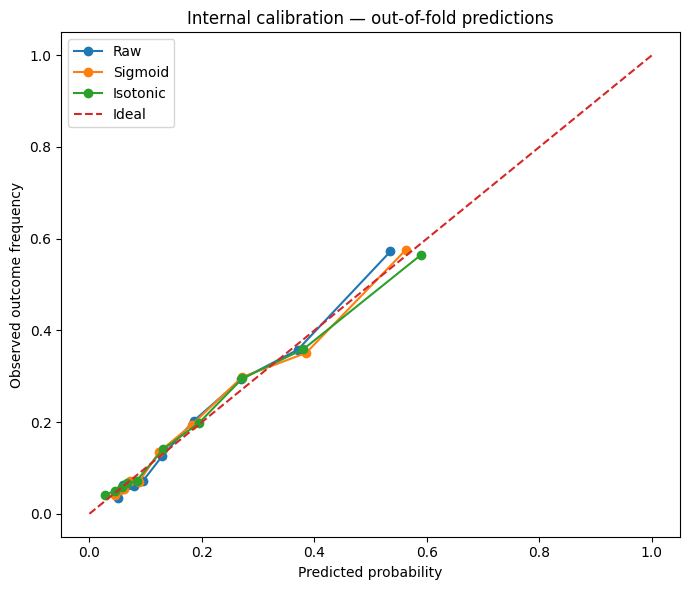

In [14]:
plt.figure(figsize=(7, 6))

for name, p in calibration_candidates.items():
    bins = pd.qcut(pd.Series(p), q=10, duplicates="drop")
    temp = pd.DataFrame({"p": p, "y": y_dev.to_numpy(), "bin": bins})
    grouped = temp.groupby("bin", observed=True).agg(
        mean_pred=("p", "mean"),
        observed=("y", "mean")
    )
    plt.plot(
        grouped["mean_pred"],
        grouped["observed"],
        marker="o",
        label=name
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Ideal")
plt.xlabel("Predicted probability")
plt.ylabel("Observed outcome frequency")
plt.title("Internal calibration — out-of-fold predictions")
plt.legend()
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "internal_calibration_oof.png",
    dpi=300
)
plt.show()

## 12. Freeze a screening operating point

Threshold-independent metrics remain primary. For one clinically interpretable
screening operating point, the threshold is chosen on development OOF predictions
to target 80% sensitivity, then frozen before temporal validation.

In [15]:
if BEST_CALIBRATION == "Sigmoid":
    selected_internal_prob = sigmoid_oof
elif BEST_CALIBRATION == "Isotonic":
    selected_internal_prob = isotonic_oof
else:
    selected_internal_prob = raw_oof_fixed

SCREENING_THRESHOLD = threshold_for_target_sensitivity(
    y_dev,
    selected_internal_prob,
    target=0.80
)

internal_operating = metrics_from_prob(
    y_dev,
    selected_internal_prob,
    threshold=SCREENING_THRESHOLD
)

print("Frozen screening threshold:", round(SCREENING_THRESHOLD, 6))
print(pd.Series(internal_operating).round(4))

Frozen screening threshold: 0.131182
roc_auc        0.7890
pr_auc         0.4650
brier          0.1223
log_loss       0.3918
accuracy       0.6774
precision      0.3404
sensitivity    0.8000
specificity    0.6497
f1             0.4776
dtype: float64


## 13. Fit the frozen final probability model

In [16]:
if BEST_CALIBRATION == "Sigmoid":
    FINAL_MODEL = clone(calibrated_sigmoid)
elif BEST_CALIBRATION == "Isotonic":
    FINAL_MODEL = clone(calibrated_isotonic)
else:
    FINAL_MODEL = clone(fixed_selected)

FINAL_MODEL.fit(X_dev, y_dev)
print("Final frozen model fitted.")

Final frozen model fitted.


## 14. Build the untouched NHANES 2021–2023 temporal validation cohort

The primary model does not require the non-harmonized PAQ variables.

In [17]:
BASE_L = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles"

def read_l(filename):
    return read_xpt_url(f"{BASE_L}/{filename}")

def select_or_nan(frame, cols, label):
    present = [c for c in cols if c in frame.columns]
    missing = [c for c in cols if c not in frame.columns]
    if missing:
        print(f"[{label}] missing: {missing}")
    out = frame[["SEQN"] + present].copy()
    for c in missing:
        out[c] = np.nan
    return out

def ckd_epi_2021(scr, age, sex_code):
    female = np.asarray(sex_code) == 2
    kappa = np.where(female, 0.7, 0.9)
    alpha = np.where(female, -0.241, -0.302)
    sex_mult = np.where(female, 1.012, 1.0)
    ratio = np.asarray(scr) / kappa

    return (
        142
        * np.minimum(ratio, 1) ** alpha
        * np.maximum(ratio, 1) ** (-1.200)
        * (0.9938 ** np.asarray(age))
        * sex_mult
    )

demo_l_full = read_l("DEMO_L.XPT")
demo_l = select_or_nan(
    demo_l_full,
    [
        "RIDAGEYR", "RIAGENDR", "RIDRETH1", "DMDEDUC2", "INDFMPIR",
        "WTMEC2YR", "SDMVPSU", "SDMVSTRA"
    ],
    "DEMO_L"
)

bio_l = select_or_nan(read_l("BIOPRO_L.XPT"), ["LBXSCR"], "BIOPRO_L")
acr_l = select_or_nan(read_l("ALB_CR_L.XPT"), ["URDACT"], "ALB_CR_L")
bpq_l = select_or_nan(read_l("BPQ_L.XPT"), ["BPQ020"], "BPQ_L")
diq_l = select_or_nan(read_l("DIQ_L.XPT"), ["DIQ010"], "DIQ_L")
bmx_l = select_or_nan(read_l("BMX_L.XPT"), ["BMXBMI", "BMXWAIST"], "BMX_L")
smq_l = select_or_nan(read_l("SMQ_L.XPT"), ["SMQ020"], "SMQ_L")
alq_l = select_or_nan(read_l("ALQ_L.XPT"), ["ALQ130"], "ALQ_L")

bpx_l = select_or_nan(
    read_l("BPXO_L.XPT"),
    ["BPXOSY1", "BPXOSY2", "BPXOSY3", "BPXODI1", "BPXODI2", "BPXODI3"],
    "BPXO_L"
)

ext = (
    demo_l
    .merge(bio_l, on="SEQN", how="inner")
    .merge(acr_l, on="SEQN", how="inner")
    .merge(bpq_l, on="SEQN", how="left")
    .merge(diq_l, on="SEQN", how="left")
    .merge(bmx_l, on="SEQN", how="left")
    .merge(smq_l, on="SEQN", how="left")
    .merge(alq_l, on="SEQN", how="left")
    .merge(bpx_l, on="SEQN", how="left")
)

ext = ext[ext["RIDAGEYR"] >= 18].copy()

ext["egfr"] = ckd_epi_2021(
    ext["LBXSCR"],
    ext["RIDAGEYR"],
    ext["RIAGENDR"]
)

ext["ckd"] = (
    (ext["egfr"] < 60) |
    (ext["URDACT"] >= 30)
).astype(int)

ext["low_egfr"] = (ext["egfr"] < 60).astype(int)
ext["albuminuria"] = (ext["URDACT"] >= 30).astype(int)

In [18]:
yn = {1: "yes", 2: "no", 7: np.nan, 9: np.nan}

ext["has_htn_dx"] = ext["BPQ020"].map(yn)
ext["has_diabetes_dx"] = ext["DIQ010"].map(yn)
ext["smoked_100_cigs"] = ext["SMQ020"].map(yn)

ext["RIAGENDR"] = ext["RIAGENDR"].map({
    1: "male",
    2: "female"
})

ext["RIDRETH1"] = ext["RIDRETH1"].map({
    1: "mexican_american",
    2: "other_hispanic",
    3: "non_hispanic_white",
    4: "non_hispanic_black",
    5: "other_or_multiracial"
})

ext["DMDEDUC2"] = ext["DMDEDUC2"].map({
    1: "less_than_9th_grade",
    2: "9th_to_11th_grade",
    3: "high_school_grad_or_GED",
    4: "some_college_or_AA_degree",
    5: "college_grad_or_above",
    7: np.nan,
    9: np.nan
})

ext["ALQ130"] = ext["ALQ130"].replace({
    777: np.nan,
    999: np.nan
})

ext["mean_sbp"] = ext[
    ["BPXOSY1", "BPXOSY2", "BPXOSY3"]
].mean(axis=1)

ext["mean_dbp"] = ext[
    ["BPXODI1", "BPXODI2", "BPXODI3"]
].mean(axis=1)

X_ext = ext[PRIMARY_FEATURES].copy()
y_ext = ext["ckd"].astype(int).copy()
w_ext = ext["WTMEC2YR"].copy()

print("Temporal validation n:", len(ext))
print("Unweighted prevalence:", round(y_ext.mean(), 4))
print(
    "Survey-weighted prevalence:",
    round(np.average(y_ext, weights=w_ext), 4)
)

Temporal validation n: 6337
Unweighted prevalence: 0.1711
Survey-weighted prevalence: 0.1393


## 15. One-time temporal validation

In [19]:
p_ext = FINAL_MODEL.predict_proba(X_ext)[:, 1]

temporal_unweighted = metrics_from_prob(
    y_ext,
    p_ext,
    threshold=SCREENING_THRESHOLD
)

temporal_weighted = metrics_from_prob(
    y_ext,
    p_ext,
    threshold=SCREENING_THRESHOLD,
    sample_weight=w_ext
)

print("Unweighted temporal performance")
display(pd.Series(temporal_unweighted).to_frame("estimate").round(4))

print("Survey-weighted temporal performance")
display(pd.Series(temporal_weighted).to_frame("estimate").round(4))

Unweighted temporal performance


,estimate
roc_auc,0.7892
pr_auc,0.4648
brier,0.1160
log_loss,0.3758
accuracy,0.6530
precision,0.3061
sensitivity,0.8118
specificity,0.6202
f1,0.4446


Survey-weighted temporal performance


,estimate
roc_auc,0.7938
pr_auc,0.4297
brier,0.0986
log_loss,0.3298
accuracy,0.7201
precision,0.2995
sensitivity,0.7537
specificity,0.7147
f1,0.4286


In [20]:
def bootstrap_ci(
    y,
    prob,
    threshold=None,
    n_boot=2000,
    seed=42
):
    y = np.asarray(y)
    prob = np.asarray(prob)

    rng = np.random.default_rng(seed)
    n = len(y)

    # Point estimates
    point = metrics_from_prob(
        y,
        prob,
        threshold=threshold
    )

    boot_rows = []

    for _ in range(n_boot):

        # Bootstrap sample with replacement
        idx = rng.integers(
            0,
            n,
            size=n
        )

        y_boot = y[idx]
        p_boot = prob[idx]

        # ROC-AUC cannot be calculated if only one class
        # happens to appear in a bootstrap sample
        if np.unique(y_boot).size < 2:
            continue

        boot_rows.append(
            metrics_from_prob(
                y_boot,
                p_boot,
                threshold=threshold
            )
        )

    boot = pd.DataFrame(boot_rows)

    ci_rows = []

    for metric, estimate in point.items():

        ci_rows.append({
            "metric": metric,
            "estimate": estimate,
            "ci_low_95": boot[metric].quantile(0.025),
            "ci_high_95": boot[metric].quantile(0.975)
        })

    ci = pd.DataFrame(ci_rows)

    return ci, boot

In [21]:
temporal_ci, temporal_boot = bootstrap_ci(
    y_ext,
    p_ext,
    threshold=SCREENING_THRESHOLD,
    n_boot=N_BOOT,
    seed=RANDOM_STATE + 500
)

display(temporal_ci.round(4))
temporal_ci.to_csv(
    RESULTS_DIR / "temporal_validation_bootstrap_CI.csv",
    index=False
)

pd.DataFrame([
    {"analysis": "temporal_unweighted", **temporal_unweighted},
    {"analysis": "temporal_survey_weighted", **temporal_weighted}
]).to_csv(
    RESULTS_DIR / "temporal_validation_metrics.csv",
    index=False
)

,metric,estimate,ci_low_95,ci_high_95
0,roc_auc,0.7892,0.7739,0.8049
1,pr_auc,0.4648,0.4340,0.4959
2,brier,0.1160,0.1110,0.1211
3,log_loss,0.3758,0.3619,0.3901
4,accuracy,0.6530,0.6404,0.6647
5,precision,0.3061,0.2888,0.3222
6,sensitivity,0.8118,0.7869,0.8350
7,specificity,0.6202,0.6065,0.6336
8,f1,0.4446,0.4244,0.4633


## 16. Temporal calibration

In [22]:
ext_intercept, ext_slope = calibration_intercept_slope(y_ext, p_ext)

temporal_calibration = {
    "brier": brier_score_loss(y_ext, p_ext),
    "calibration_intercept": ext_intercept,
    "calibration_slope": ext_slope,
    "ece": weighted_ece(y_ext, p_ext, 10)
}

temporal_calibration_weighted = {
    "brier": brier_score_loss(
        y_ext, p_ext, sample_weight=w_ext
    ),
    "ece": weighted_ece(
        y_ext, p_ext, 10, sample_weight=w_ext
    )
}

print("Temporal calibration")
print(temporal_calibration)
print("Survey-weighted calibration sensitivity")
print(temporal_calibration_weighted)

Temporal calibration
{'brier': np.float64(0.11599522129206719), 'calibration_intercept': 0.02381057214369518, 'calibration_slope': 1.0755788154385315, 'ece': 0.012835885198123908}
Survey-weighted calibration sensitivity
{'brier': np.float64(0.09864231083005247), 'ece': 0.011623211277826864}


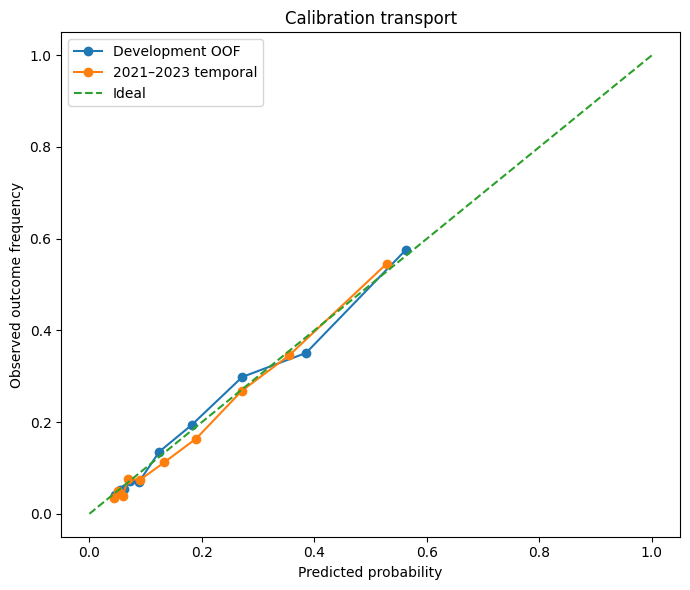

In [23]:
plt.figure(figsize=(7, 6))

for label, yy, pp in [
    ("Development OOF", y_dev.to_numpy(), selected_internal_prob),
    ("2021–2023 temporal", y_ext.to_numpy(), p_ext)
]:
    bins = pd.qcut(pd.Series(pp), q=10, duplicates="drop")
    temp = pd.DataFrame({"p": pp, "y": yy, "bin": bins})
    grouped = temp.groupby("bin", observed=True).agg(
        mean_pred=("p", "mean"),
        observed=("y", "mean")
    )
    plt.plot(
        grouped["mean_pred"],
        grouped["observed"],
        marker="o",
        label=label
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Ideal")
plt.xlabel("Predicted probability")
plt.ylabel("Observed outcome frequency")
plt.title("Calibration transport")
plt.legend()
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "calibration_transport.png",
    dpi=300
)
plt.show()

## 17. Decision-curve analysis

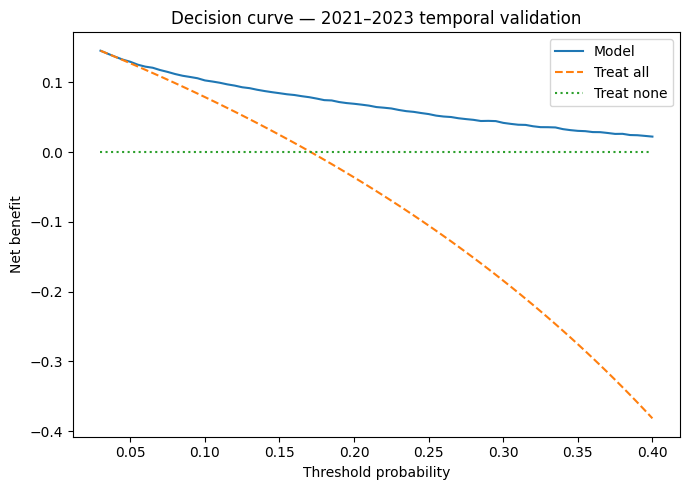

In [24]:
def decision_curve(y, p, thresholds=None, sample_weight=None):
    y = np.asarray(y)
    p = np.asarray(p)

    if thresholds is None:
        thresholds = np.linspace(0.03, 0.40, 75)

    w = (
        np.ones(len(y), dtype=float)
        if sample_weight is None
        else np.asarray(sample_weight, dtype=float)
    )

    total_w = w.sum()
    prevalence = np.average(y, weights=w)

    rows = []
    for pt in thresholds:
        pred = p >= pt

        tp_w = w[(pred == 1) & (y == 1)].sum()
        fp_w = w[(pred == 1) & (y == 0)].sum()

        nb_model = (
            tp_w / total_w -
            fp_w / total_w * pt / (1 - pt)
        )
        nb_all = prevalence - (1 - prevalence) * pt / (1 - pt)

        rows.append({
            "threshold": pt,
            "model": nb_model,
            "treat_all": nb_all,
            "treat_none": 0.0
        })

    return pd.DataFrame(rows)

dca_dev = decision_curve(y_dev, selected_internal_prob)
dca_ext = decision_curve(y_ext, p_ext)
dca_ext_weighted = decision_curve(y_ext, p_ext, sample_weight=w_ext)

dca_dev.to_csv(RESULTS_DIR / "dca_development_oof.csv", index=False)
dca_ext.to_csv(RESULTS_DIR / "dca_temporal.csv", index=False)
dca_ext_weighted.to_csv(
    RESULTS_DIR / "dca_temporal_weighted.csv",
    index=False
)

plt.figure(figsize=(7, 5))
plt.plot(dca_ext["threshold"], dca_ext["model"], label="Model")
plt.plot(dca_ext["threshold"], dca_ext["treat_all"], linestyle="--", label="Treat all")
plt.plot(dca_ext["threshold"], dca_ext["treat_none"], linestyle=":", label="Treat none")
plt.xlabel("Threshold probability")
plt.ylabel("Net benefit")
plt.title("Decision curve — 2021–2023 temporal validation")
plt.legend()
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "decision_curve_temporal.png",
    dpi=300
)
plt.show()

## 18. Age-coupling sensitivity

In [25]:
AGE_FREE_FEATURES = [
    c for c in PRIMARY_FEATURES
    if c != "RIDAGEYR"
]

X_dev_agefree = df[AGE_FREE_FEATURES].copy()
X_ext_agefree = ext[AGE_FREE_FEATURES].copy()

agefree_model_template = clone(
    selected_spec["pipeline"].named_steps["model"]
)
agefree_pipeline = make_pipeline(
    agefree_model_template,
    X_dev_agefree
)

agefree_search = RandomizedSearchCV(
    agefree_pipeline,
    selected_spec["params"],
    n_iter=N_ITER,
    scoring="roc_auc",
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE + 700
    ),
    random_state=RANDOM_STATE + 700,
    n_jobs=-1,
    refit=True
)

agefree_oof = cross_val_predict(
    agefree_search,
    X_dev_agefree,
    y_dev,
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE + 701
    ),
    method="predict_proba",
    n_jobs=-1
)[:, 1]

agefree_internal = metrics_from_prob(y_dev, agefree_oof)

agefree_search.fit(X_dev_agefree, y_dev)
agefree_final = agefree_search.best_estimator_
p_ext_agefree = agefree_final.predict_proba(X_ext_agefree)[:, 1]
agefree_temporal = metrics_from_prob(y_ext, p_ext_agefree)

age_sensitivity = pd.DataFrame([
    {
        "analysis": "Primary model",
        "internal_auc": roc_auc_score(y_dev, selected_internal_prob),
        "temporal_auc": roc_auc_score(y_ext, p_ext)
    },
    {
        "analysis": "Age removed",
        "internal_auc": agefree_internal["roc_auc"],
        "temporal_auc": agefree_temporal["roc_auc"]
    }
])

display(age_sensitivity.round(4))
age_sensitivity.to_csv(
    RESULTS_DIR / "age_coupling_sensitivity.csv",
    index=False
)

,analysis,internal_auc,temporal_auc
0,Primary model,0.7890,0.7892
1,Age removed,0.7618,0.7424


## 19. Outcome-component sensitivity

Separately evaluate low eGFR and albuminuria in the temporal cohort.

In [26]:
component_rows = []

for outcome_name in ["low_egfr", "albuminuria", "ckd"]:
    yy = ext[outcome_name].astype(int)

    component_rows.append({
        "outcome": outcome_name,
        "prevalence": yy.mean(),
        "roc_auc": roc_auc_score(yy, p_ext),
        "pr_auc": average_precision_score(yy, p_ext),
        "brier": brier_score_loss(yy, p_ext)
    })

outcome_component_results = pd.DataFrame(component_rows)
display(outcome_component_results.round(4))
outcome_component_results.to_csv(
    RESULTS_DIR / "outcome_component_sensitivity.csv",
    index=False
)

,outcome,prevalence,roc_auc,pr_auc,brier
0,low_egfr,0.0753,0.8437,0.2863,0.0744
1,albuminuria,0.1184,0.7411,0.3060,0.1013
2,ckd,0.1711,0.7892,0.4648,0.1160


## 20. Race/activity predictor sensitivity

In [27]:
SENSITIVITY_FEATURE_SETS = {
    "Primary": PRIMARY_FEATURES,
    "Primary_plus_race": PRIMARY_FEATURES + ["RIDRETH1"],
}

pa_cols = ["PAQ605", "PAQ620", "PAQ635", "PAQ650", "PAQ665"]
if all(c in df.columns for c in pa_cols):
    df["activity_any"] = (
        (df[pa_cols] == "yes").any(axis=1)
    ).astype(float)
    df.loc[df[pa_cols].isna().all(axis=1), "activity_any"] = np.nan
    SENSITIVITY_FEATURE_SETS["Primary_plus_activity"] = (
        PRIMARY_FEATURES + ["activity_any"]
    )

feature_sensitivity_rows = []

for label, cols in SENSITIVITY_FEATURE_SETS.items():
    XX = df[cols].copy()

    template = clone(
        selected_spec["pipeline"].named_steps["model"]
    )
    pipe = make_pipeline(template, XX)

    search = RandomizedSearchCV(
        pipe,
        selected_spec["params"],
        n_iter=max(10, N_ITER // 2),
        scoring="roc_auc",
        cv=StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=RANDOM_STATE + 800
        ),
        random_state=RANDOM_STATE + 800,
        n_jobs=-1
    )

    oof = cross_val_predict(
        search,
        XX,
        y_dev,
        cv=StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=RANDOM_STATE + 801
        ),
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    feature_sensitivity_rows.append({
        "feature_set": label,
        **metrics_from_prob(y_dev, oof)
    })

feature_sensitivity = pd.DataFrame(feature_sensitivity_rows)
display(feature_sensitivity.round(4))
feature_sensitivity.to_csv(
    RESULTS_DIR / "race_activity_feature_sensitivity.csv",
    index=False
)

,feature_set,roc_auc,pr_auc,brier,log_loss
0,Primary,0.7834,0.4704,0.1229,0.3954
1,Primary_plus_race,0.7860,0.4801,0.1220,0.3932
2,Primary_plus_activity,0.7836,0.4694,0.1231,0.3956


## 21. Subgroup performance heterogeneity with bootstrap CIs

In [28]:
ext_eval = ext.copy()
ext_eval["prob"] = p_ext
ext_eval["age_group"] = pd.cut(
    ext_eval["RIDAGEYR"],
    bins=[17, 39, 59, np.inf],
    labels=["18-39", "40-59", "60+"]
)

def subgroup_bootstrap(
    data,
    group_var,
    y_col="ckd",
    p_col="prob",
    threshold=SCREENING_THRESHOLD,
    n_boot=1000,
    min_cases=10,
    min_controls=10,
    seed=RANDOM_STATE
):
    rng = np.random.default_rng(seed)
    rows = []

    for level, g in data.groupby(group_var, dropna=False, observed=False):
        y = g[y_col].to_numpy(dtype=int)
        p = g[p_col].to_numpy(dtype=float)
        n = len(g)
        cases = int(y.sum())
        controls = n - cases

        base = {
            "variable": group_var,
            "subgroup": str(level),
            "n": n,
            "cases": cases,
            "controls": controls
        }

        if cases < min_cases or controls < min_controls:
            rows.append({
                **base,
                "status": "insufficient_events"
            })
            continue

        point = metrics_from_prob(y, p, threshold)

        boot = []
        for _ in range(n_boot):
            idx = rng.integers(0, n, n)
            yy = y[idx]
            pp = p[idx]
            if np.unique(yy).size < 2:
                continue
            boot.append(metrics_from_prob(yy, pp, threshold))

        boot = pd.DataFrame(boot)

        row = {**base, "status": "evaluated"}
        for metric in ["roc_auc", "sensitivity", "specificity", "pr_auc"]:
            row[metric] = point[metric]
            row[metric + "_ci_low"] = boot[metric].quantile(0.025)
            row[metric + "_ci_high"] = boot[metric].quantile(0.975)

        rows.append(row)

    return pd.DataFrame(rows)

subgroup_frames = []
for var in [
    "RIAGENDR",
    "RIDRETH1",
    "age_group",
    "has_diabetes_dx",
    "has_htn_dx"
]:
    subgroup_frames.append(
        subgroup_bootstrap(
            ext_eval,
            var,
            n_boot=1000,
            seed=RANDOM_STATE + 900
        )
    )

subgroup_results = pd.concat(subgroup_frames, ignore_index=True)
display(subgroup_results.round(4))
subgroup_results.to_csv(
    RESULTS_DIR / "temporal_subgroup_performance_with_CI.csv",
    index=False
)

,variable,subgroup,n,cases,controls,status,roc_auc,roc_auc_ci_low,roc_auc_ci_high,sensitivity,sensitivity_ci_low,sensitivity_ci_high,specificity,specificity_ci_low,specificity_ci_high,pr_auc,pr_auc_ci_low,pr_auc_ci_high
0,RIAGENDR,female,3479,568,2911,evaluated,0.7615,0.7399,0.7841,0.7764,0.7425,0.8107,0.6235,0.6056,0.6405,0.4138,0.3758,0.4575
1,RIAGENDR,male,2858,516,2342,evaluated,0.8195,0.7991,0.8392,0.8508,0.8198,0.8804,0.6161,0.5961,0.6373,0.5291,0.4852,0.5716
2,RIDRETH1,mexican_american,448,54,394,evaluated,0.7347,0.6508,0.8132,0.6667,0.5366,0.7959,0.7437,0.7010,0.7884,0.3586,0.2477,0.5067
3,RIDRETH1,non_hispanic_black,791,187,604,evaluated,0.7863,0.7473,0.8215,0.8021,0.7446,0.8563,0.5960,0.5533,0.6372,0.5258,0.4506,0.6024
4,RIDRETH1,non_hispanic_white,3684,626,3058,evaluated,0.7986,0.7783,0.8178,0.8482,0.8175,0.8752,0.5932,0.5756,0.6099,0.4743,0.4322,0.5143
5,RIDRETH1,other_hispanic,647,89,558,evaluated,0.7390,0.6862,0.7923,0.6854,0.5926,0.7788,0.6667,0.6278,0.7064,0.3682,0.2749,0.4727
6,RIDRETH1,other_or_multiracial,767,128,639,evaluated,0.7957,0.7481,0.8358,0.7969,0.7234,0.8682,0.6557,0.6180,0.6915,0.4945,0.3966,0.5885
7,age_group,18-39,1832,104,1728,evaluated,0.6310,0.5656,0.6928,0.1731,0.1058,0.2473,0.9734,0.9660,0.9809,0.1476,0.1011,0.2219
8,age_group,40-59,1733,215,1518,evaluated,0.7243,0.6887,0.7605,0.6047,0.5349,0.6695,0.7424,0.7207,0.7619,0.3119,0.2545,0.3763
9,age_group,60+,2772,765,2007,evaluated,0.7495,0.7313,0.7689,0.9569,0.9422,0.9716,0.2237,0.2052,0.2429,0.5280,0.4946,0.5661


## Subgroup calibration sensitivity

Because the frozen global threshold behaved differently across age and
cardiometabolic-risk strata, evaluate whether the *probabilities themselves*
remain calibrated within key subgroups.

This analysis does **not** tune subgroup-specific thresholds.

In [29]:
def subgroup_calibration_table(
    data,
    group_var,
    y_col="ckd",
    p_col="prob",
    min_cases=20,
    min_controls=20
):
    rows = []

    for level, g in data.groupby(group_var, dropna=False, observed=False):
        y = g[y_col].to_numpy(dtype=int)
        p = g[p_col].to_numpy(dtype=float)
        n = len(g)
        cases = int(y.sum())
        controls = n - cases

        row = {
            "variable": group_var,
            "subgroup": str(level),
            "n": n,
            "cases": cases,
            "controls": controls
        }

        if cases < min_cases or controls < min_controls:
            row["status"] = "insufficient_events"
            rows.append(row)
            continue

        intercept, slope = calibration_intercept_slope(y, p)

        row.update({
            "status": "evaluated",
            "brier": brier_score_loss(y, p),
            "calibration_intercept": intercept,
            "calibration_slope": slope,
            "ece": weighted_ece(y, p, 10)
        })
        rows.append(row)

    return pd.DataFrame(rows)

subgroup_calibration_frames = []

for var in [
    "RIAGENDR",
    "age_group",
    "has_diabetes_dx",
    "has_htn_dx"
]:
    subgroup_calibration_frames.append(
        subgroup_calibration_table(ext_eval, var)
    )

subgroup_calibration = pd.concat(
    subgroup_calibration_frames,
    ignore_index=True
)

display(subgroup_calibration.round(4))
subgroup_calibration.to_csv(
    RESULTS_DIR / "temporal_subgroup_calibration.csv",
    index=False
)

,variable,subgroup,n,cases,controls,status,brier,calibration_intercept,calibration_slope,ece
0,RIAGENDR,female,3479,568,2911,evaluated,0.1171,-0.1655,0.9487,0.0142
1,RIAGENDR,male,2858,516,2342,evaluated,0.1147,0.2479,1.2415,0.0259
2,age_group,18-39,1832,104,1728,evaluated,0.0518,0.8205,1.3663,0.0174
3,age_group,40-59,1733,215,1518,evaluated,0.0987,0.1276,1.0457,0.0171
4,age_group,60+,2772,765,2007,evaluated,0.1692,0.0482,1.1973,0.0234
5,has_diabetes_dx,no,5243,677,4566,evaluated,0.0973,-0.0440,1.0467,0.0127
6,has_diabetes_dx,yes,870,352,518,evaluated,0.2163,0.0905,1.2021,0.0491
7,has_diabetes_dx,nan,224,55,169,evaluated,0.1639,0.2191,1.0230,0.0692
8,has_htn_dx,no,4010,390,3620,evaluated,0.0804,-0.0423,1.0207,0.0085
9,has_htn_dx,yes,2323,694,1629,evaluated,0.1774,0.0831,1.2038,0.0226


## 21a. Age-stratified screening thresholds — subgroup mitigation analysis

The single global threshold (Section 12) was frozen to hit 80% sensitivity in
the *overall* development cohort. Section 21 showed that this single threshold
behaves very unevenly across age and cardiometabolic-risk subgroups — most
strikingly, sensitivity of only 0.17 in adults 18–39 versus 0.96 in adults 60+,
and a diabetes subgroup where the global threshold drives specificity to
essentially zero.

This section tests one candidate mitigation: **age-stratified thresholds**,
each targeting the same 80% sensitivity criterion but derived *within* each
development-cohort age stratum rather than pooled across all ages. This keeps
the core methodological principle of the paper intact — every threshold is
still selected from development out-of-fold (OOF) predictions only, and then
frozen and applied unchanged to the temporal cohort — it simply asks whether
letting the operating point vary by age closes the sensitivity gap without
destroying specificity in the oldest group.

This is an exploratory, pre-registered-in-spirit sensitivity analysis, not a
replacement for the primary single-threshold result. If it works well, it is
strong evidence that subgroup heterogeneity is addressable within the existing
pipeline; if it does not, that is also an informative (and reportable) result.


In [30]:
# ---------------------------------------------------------------
# Age-stratified thresholds, derived from development OOF only
# ---------------------------------------------------------------

dev_age = df["RIDAGEYR"].to_numpy()
dev_age_group = pd.cut(
    dev_age,
    bins=[17, 39, 59, np.inf],
    labels=["18-39", "40-59", "60+"]
)

age_thresholds = {}
for level in ["18-39", "40-59", "60+"]:
    mask = (dev_age_group == level)
    y_g = y_dev.to_numpy()[mask]
    p_g = np.asarray(selected_internal_prob)[mask]
    t_g = threshold_for_target_sensitivity(y_g, p_g, target=0.80)
    age_thresholds[level] = t_g

    dev_op = metrics_from_prob(y_g, p_g, threshold=t_g)
    print(
        f"[{level}] development n={mask.sum()}, "
        f"frozen threshold={t_g:.6f}, "
        f"dev sensitivity={dev_op['sensitivity']:.4f}, "
        f"dev specificity={dev_op['specificity']:.4f}"
    )

print("\nFrozen age-stratified thresholds (development OOF only):")
print(age_thresholds)


[18-39] development n=1857, frozen threshold=0.051183, dev sensitivity=0.8017, dev specificity=0.2811
[40-59] development n=1658, frozen threshold=0.098900, dev sensitivity=0.8009, dev specificity=0.5743
[60+] development n=2018, frozen threshold=0.274782, dev sensitivity=0.8009, dev specificity=0.5045

Frozen age-stratified thresholds (development OOF only):
{'18-39': 0.051183403274395536, '40-59': 0.09890028693592652, '60+': 0.2747823409323764}


### Applying the frozen age-stratified thresholds to the temporal cohort

The thresholds above were selected using development data exclusively, exactly
as in Section 12. They are now applied — unchanged — to the temporal
2021–2023 cohort, split by the same age bands, and compared against the single
global threshold already reported in Table 7 of the manuscript.


In [31]:
# ---------------------------------------------------------------
# Apply frozen age-stratified thresholds to the 2021-2023 cohort
# ---------------------------------------------------------------

ext_eval["age_stratified_pred"] = np.nan

rows = []
for level in ["18-39", "40-59", "60+"]:
    mask = (ext_eval["age_group"] == level)
    y_g = ext_eval.loc[mask, "ckd"].to_numpy(dtype=int)
    p_g = ext_eval.loc[mask, "prob"].to_numpy(dtype=float)
    t_g = age_thresholds[level]

    global_metrics = metrics_from_prob(y_g, p_g, threshold=SCREENING_THRESHOLD)
    strat_metrics = metrics_from_prob(y_g, p_g, threshold=t_g)

    rows.append({
        "age_group": level,
        "n": int(mask.sum()),
        "cases": int(y_g.sum()),
        "global_threshold": SCREENING_THRESHOLD,
        "global_sensitivity": global_metrics["sensitivity"],
        "global_specificity": global_metrics["specificity"],
        "stratified_threshold": t_g,
        "stratified_sensitivity": strat_metrics["sensitivity"],
        "stratified_specificity": strat_metrics["specificity"],
    })

age_strat_comparison = pd.DataFrame(rows)
display(age_strat_comparison.round(4))

age_strat_comparison.to_csv(
    RESULTS_DIR / "temporal_age_stratified_threshold_comparison.csv",
    index=False
)

# Overall pooled performance if age-stratified thresholds were used
# instead of the single global threshold, computed across the whole
# temporal cohort (pooling predictions made under each participant's
# own age-specific threshold).
pooled_pred = np.zeros(len(ext_eval), dtype=int)
for level in ["18-39", "40-59", "60+"]:
    mask = (ext_eval["age_group"] == level).to_numpy()
    pooled_pred[mask] = (
        ext_eval.loc[mask, "prob"].to_numpy() >= age_thresholds[level]
    ).astype(int)

y_all = ext_eval["ckd"].to_numpy(dtype=int)
pooled_sensitivity = recall_score(y_all, pooled_pred, zero_division=0)
pooled_specificity = safe_specificity(y_all, pooled_pred)

print(
    f"\nPooled temporal performance under age-stratified thresholds: "
    f"sensitivity={pooled_sensitivity:.4f}, specificity={pooled_specificity:.4f}"
)
print(
    f"Pooled temporal performance under the single global threshold: "
    f"sensitivity={temporal_unweighted['sensitivity']:.4f}, "
    f"specificity={temporal_unweighted['specificity']:.4f}"
)


,age_group,n,cases,global_threshold,global_sensitivity,global_specificity,stratified_threshold,stratified_sensitivity,stratified_specificity
0,18-39,1832,104,0.1312,0.1731,0.9734,0.0512,0.7500,0.3704
1,40-59,1733,215,0.1312,0.6047,0.7424,0.0989,0.6884,0.6377
2,60+,2772,765,0.1312,0.9569,0.2237,0.2748,0.7804,0.5845



Pooled temporal performance under age-stratified thresholds: sensitivity=0.7592, specificity=0.5294
Pooled temporal performance under the single global threshold: sensitivity=0.8118, specificity=0.6202


### Diabetes-tier thresholds (same approach, applied to diagnosed-diabetes status)

The diabetes subgroup showed the most extreme threshold failure in Section 21
(sensitivity 1.00, specificity 0.004 under the global threshold). The same
stratified-threshold logic is repeated here for `has_diabetes_dx`, again using
development OOF predictions only.


In [32]:
# ---------------------------------------------------------------
# Diabetes-tier thresholds, derived from development OOF only
# ---------------------------------------------------------------

dev_diabetes = df["has_diabetes_dx"].to_numpy()

diabetes_thresholds = {}
for level in ["no", "yes"]:
    mask = (dev_diabetes == level)
    y_g = y_dev.to_numpy()[mask]
    p_g = np.asarray(selected_internal_prob)[mask]
    t_g = threshold_for_target_sensitivity(y_g, p_g, target=0.80)
    diabetes_thresholds[level] = t_g

    dev_op = metrics_from_prob(y_g, p_g, threshold=t_g)
    print(
        f"[diabetes={level}] development n={mask.sum()}, "
        f"frozen threshold={t_g:.6f}, "
        f"dev sensitivity={dev_op['sensitivity']:.4f}, "
        f"dev specificity={dev_op['specificity']:.4f}"
    )

rows = []
for level in ["no", "yes"]:
    mask = (ext_eval["has_diabetes_dx"] == level)
    y_g = ext_eval.loc[mask, "ckd"].to_numpy(dtype=int)
    p_g = ext_eval.loc[mask, "prob"].to_numpy(dtype=float)
    t_g = diabetes_thresholds[level]

    global_metrics = metrics_from_prob(y_g, p_g, threshold=SCREENING_THRESHOLD)
    strat_metrics = metrics_from_prob(y_g, p_g, threshold=t_g)

    rows.append({
        "diabetes_dx": level,
        "n": int(mask.sum()),
        "cases": int(y_g.sum()),
        "global_threshold": SCREENING_THRESHOLD,
        "global_sensitivity": global_metrics["sensitivity"],
        "global_specificity": global_metrics["specificity"],
        "stratified_threshold": t_g,
        "stratified_sensitivity": strat_metrics["sensitivity"],
        "stratified_specificity": strat_metrics["specificity"],
    })

diabetes_strat_comparison = pd.DataFrame(rows)
display(diabetes_strat_comparison.round(4))

diabetes_strat_comparison.to_csv(
    RESULTS_DIR / "temporal_diabetes_stratified_threshold_comparison.csv",
    index=False
)


[diabetes=no] development n=4526, frozen threshold=0.084934, dev sensitivity=0.8000, dev specificity=0.5793
[diabetes=yes] development n=838, frozen threshold=0.327836, dev sensitivity=0.8022, dev specificity=0.3861


,diabetes_dx,n,cases,global_threshold,global_sensitivity,global_specificity,stratified_threshold,stratified_sensitivity,stratified_specificity
0,no,5243,677,0.1312,0.7061,0.6969,0.0849,0.7888,0.5653
1,yes,870,352,0.1312,1.0000,0.0039,0.3278,0.7926,0.4189


## 22. Imbalance-method sensitivity — secondary analysis only

In [33]:
def selected_base_estimator():
    return clone(
        selected_spec["pipeline"].named_steps["model"]
    )

imbalance_pipelines = {
    "none": Pipeline([
        ("prep", make_preprocessor(X_dev)),
        ("model", selected_base_estimator())
    ]),

    "smote": ImbPipeline([
        ("prep", make_preprocessor(X_dev)),
        ("resample", SMOTE(random_state=RANDOM_STATE)),
        ("model", selected_base_estimator())
    ]),

    "smoteenn": ImbPipeline([
        ("prep", make_preprocessor(X_dev)),
        ("resample", SMOTEENN(random_state=RANDOM_STATE)),
        ("model", selected_base_estimator())
    ])
}

cw_model = selected_base_estimator()
if "class_weight" in cw_model.get_params():
    cw_model.set_params(class_weight="balanced")
    imbalance_pipelines["class_weight"] = Pipeline([
        ("prep", make_preprocessor(X_dev)),
        ("model", cw_model)
    ])

imbalance_rows = []
cv_imb = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE + 1000
)

for name, pipe in imbalance_pipelines.items():
    p = cross_val_predict(
        pipe,
        X_dev,
        y_dev,
        cv=cv_imb,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    imbalance_rows.append({
        "strategy": name,
        **metrics_from_prob(y_dev, p)
    })

imbalance_results = pd.DataFrame(imbalance_rows)
display(imbalance_results.round(4))
imbalance_results.to_csv(
    RESULTS_DIR / "imbalance_sensitivity.csv",
    index=False
)

,strategy,roc_auc,pr_auc,brier,log_loss
0,none,0.7640,0.4279,0.1312,0.4229
1,smote,0.7601,0.4181,0.1396,0.4380
2,smoteenn,0.7641,0.4430,0.2044,0.7039
3,class_weight,0.7656,0.4417,0.1565,0.4817


## 23. Survey-weighted evaluation sensitivity

In [34]:
w_dev = survey_dev["WTMEC2YR"].to_numpy()

weighted_dev_metrics = metrics_from_prob(
    y_dev,
    selected_internal_prob,
    threshold=SCREENING_THRESHOLD,
    sample_weight=w_dev
)

weighted_ext_metrics = metrics_from_prob(
    y_ext,
    p_ext,
    threshold=SCREENING_THRESHOLD,
    sample_weight=w_ext
)

survey_weighted_table = pd.DataFrame([
    {"cohort": "2017-2018 development OOF", **weighted_dev_metrics},
    {"cohort": "2021-2023 temporal", **weighted_ext_metrics}
])

display(survey_weighted_table.round(4))
survey_weighted_table.to_csv(
    RESULTS_DIR / "survey_weighted_performance.csv",
    index=False
)

,cohort,roc_auc,pr_auc,brier,log_loss,accuracy,precision,sensitivity,specificity,f1
0,2017-2018 development OOF,0.7852,0.4017,0.0978,0.3286,0.7264,0.2963,0.7342,0.7252,0.4222
1,2021-2023 temporal,0.7938,0.4297,0.0986,0.3298,0.7201,0.2995,0.7537,0.7147,0.4286


## 24. Model-agnostic temporal permutation importance

,feature,importance_mean,importance_sd
0,RIDAGEYR,0.1151,0.0054
5,has_diabetes_dx,0.0292,0.0028
4,has_htn_dx,0.0175,0.0026
10,mean_sbp,0.0100,0.0017
3,INDFMPIR,0.0045,0.0011
6,BMXBMI,0.0034,0.0008
2,DMDEDUC2,0.0014,0.0006
11,mean_dbp,0.0011,0.0002
1,RIAGENDR,0.0004,0.0002
7,BMXWAIST,0.0001,0.0004


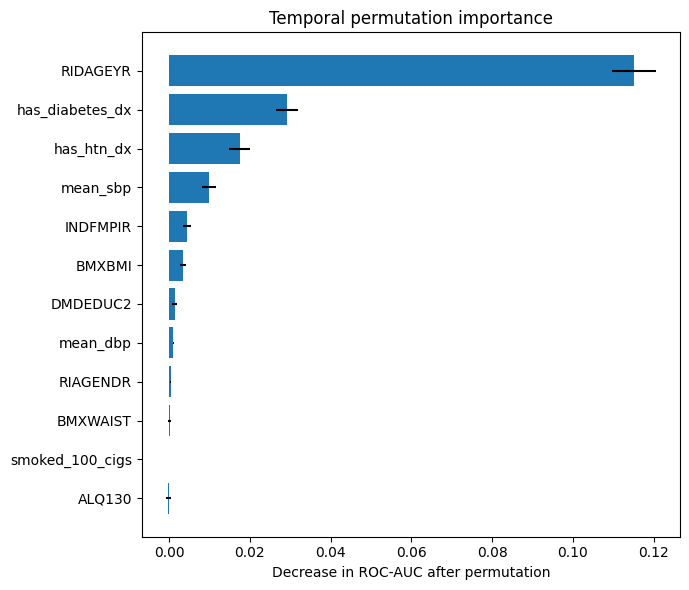

In [35]:
perm = permutation_importance(
    FINAL_MODEL,
    X_ext,
    y_ext,
    scoring="roc_auc",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_ext.columns,
    "importance_mean": perm.importances_mean,
    "importance_sd": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(perm_df.round(4))
perm_df.to_csv(
    RESULTS_DIR / "temporal_permutation_importance.csv",
    index=False
)

plt.figure(figsize=(7, 6))
plot_df = perm_df.sort_values("importance_mean")
plt.barh(
    plot_df["feature"],
    plot_df["importance_mean"],
    xerr=plot_df["importance_sd"]
)
plt.xlabel("Decrease in ROC-AUC after permutation")
plt.title("Temporal permutation importance")
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "temporal_permutation_importance.png",
    dpi=300
)
plt.show()

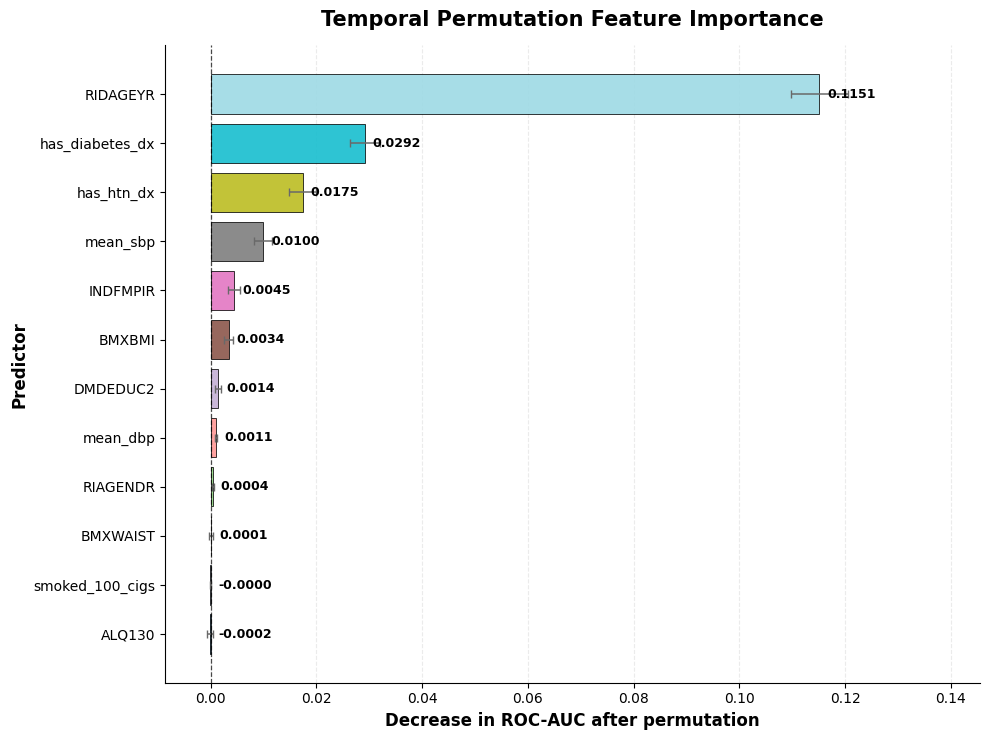

In [39]:
# ============================================================
# Temporal Permutation Importance Plot
# Numbers shown to the RIGHT of every bar
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

plot_df = perm_df.sort_values("importance_mean", ascending=True).copy()

# Different color for every bar
colors = plt.cm.tab20(np.linspace(0, 1, len(plot_df)))

fig, ax = plt.subplots(figsize=(10, 7.5))

bars = ax.barh(
    plot_df["feature"],
    plot_df["importance_mean"],
    xerr=plot_df["importance_sd"],
    color=colors,
    edgecolor="black",
    linewidth=0.6,
    alpha=0.90,
    error_kw={
        "ecolor": "dimgray",
        "elinewidth": 1.1,
        "capsize": 3
    }
)

# Zero reference line
ax.axvline(
    0,
    color="black",
    linewidth=0.9,
    linestyle="--",
    alpha=0.7
)

# ------------------------------------------------------------
# Add numeric value to the RIGHT of every bar
# ------------------------------------------------------------

label_padding = 0.0015

for bar, value in zip(bars, plot_df["importance_mean"]):

    y = bar.get_y() + bar.get_height() / 2

    # Positive values:
    # place label after the end of the bar
    if value > 0:
        x_text = value + label_padding

    # Zero or negative values:
    # place label just to the right of zero
    else:
        x_text = label_padding

    ax.text(
        x_text,
        y,
        f"{value:.4f}",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold"
    )

# Axis labels
ax.set_xlabel(
    "Decrease in ROC-AUC after permutation",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Predictor",
    fontsize=12,
    fontweight="bold"
)

ax.set_title(
    "Temporal Permutation Feature Importance",
    fontsize=15,
    fontweight="bold",
    pad=14
)

# Grid
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    axis="both",
    labelsize=10
)

# Give enough space on left and right
xmin = min(
    plot_df["importance_mean"].min() -
    plot_df["importance_sd"].max() - 0.003,
    -0.005
)

xmax = (
    plot_df["importance_mean"].max()
    + plot_df["importance_sd"].max()
    + 0.025
)

ax.set_xlim(xmin, xmax)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "temporal_permutation_importance.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

## 25. Reproducibility record and master table

In [36]:
import sklearn
import lightgbm
import xgboost
import imblearn
import statsmodels

environment = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "sklearn": sklearn.__version__,
    "lightgbm": lightgbm.__version__,
    "xgboost": xgboost.__version__,
    "imbalanced_learn": imblearn.__version__,
    "statsmodels": statsmodels.__version__,
    "random_state": RANDOM_STATE,
    "outer_folds": OUTER_FOLDS,
    "inner_folds": INNER_FOLDS,
    "n_iter": N_ITER,
    "selected_model": SELECTED_MODEL_NAME,
    "best_calibration": BEST_CALIBRATION,
    "screening_threshold_target_sensitivity": 0.80,
    "screening_threshold": SCREENING_THRESHOLD,
    "primary_features": PRIMARY_FEATURES,
    "final_params": final_search.best_params_
}

with open(RESULTS_DIR / "reproducibility_environment.json", "w") as f:
    json.dump(environment, f, indent=2, default=str)

master = pd.DataFrame([
    {
        "cohort": "2017-2018 internal OOF",
        **metrics_from_prob(
            y_dev,
            selected_internal_prob,
            SCREENING_THRESHOLD
        )
    },
    {
        "cohort": "2021-2023 temporal validation",
        **metrics_from_prob(
            y_ext,
            p_ext,
            SCREENING_THRESHOLD
        )
    }
])

display(master.round(4))
master.to_csv(
    RESULTS_DIR / "MASTER_PERFORMANCE_TABLE.csv",
    index=False
)

print("\nAll outputs saved to:")
print(RESULTS_DIR)

,cohort,roc_auc,pr_auc,brier,log_loss,accuracy,precision,sensitivity,specificity,f1
0,2017-2018 internal OOF,0.7890,0.4650,0.1223,0.3918,0.6774,0.3404,0.8000,0.6497,0.4776
1,2021-2023 temporal validation,0.7892,0.4648,0.1160,0.3758,0.6530,0.3061,0.8118,0.6202,0.4446



All outputs saved to:
/content/drive/MyDrive/Shuvo-Paper/mlwa_research_grade_results


# Reporting guidance for the revised manuscript

### Main analyses
- Nested-CV model comparison
- Calibration and discrimination from out-of-fold development predictions
- Frozen 2021–2023 temporal transport validation
- Temporal calibration
- Decision-curve analysis
- Survey-weighted sensitivity analysis

### Sensitivity analyses
- Age removed
- eGFR-only versus albuminuria-only outcome components
- Race added versus excluded
- Physical activity added internally only
- Alternative imbalance strategies
- Subgroup performance heterogeneity with confidence intervals

### Terminology
- Prefer **single-visit CKD screening phenotype** or **CKD markers** over confirmed
  CKD when the outcome is based on one NHANES examination.
- Prefer **temporal validation/transport evaluation** over independent external
  validation.
- Do not claim complex ML superiority unless paired uncertainty supports it.
- Do not call subgroup analysis proof of fairness.
- Do not interpret probabilities as individual clinical risk unless calibration
  is adequate.

### Final statistical interpretation rule
- Rank candidate models by **mean outer-fold nested-CV performance**, not pooled
  OOF ROC-AUC from separately tuned folds.
- If several models are within one standard error of the best mean AUC, favor
  the one with better probabilistic performance (lower Brier/log loss).
- Do not claim statistical superiority from pooled OOF pairwise bootstrap
  comparisons across separately tuned folds.